<a href="https://colab.research.google.com/github/sauraviitj/neural-networks-zero-to-hero/blob/main/2%20%2C%203%2C%204%20Makemore/makemore_part2_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementation of perceptron to predict the next character in a sequence
[Bengio et al. 2003](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [53]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [41]:
len(words)

32033

a. ''.join(words) joins ll words. its type is str.
b. set() chooses unique letters, set doesnt allow duplicates type is set
c. list converts it to list so that sorted can be applied
```
#build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
#print(chars)
stoi ={} #empty dictionery
itos= {}
#enumerate() tracks the position of each item in a loop by automatically counting them as you iterate.
for i,c in enumerate(chars):
  stoi[c] =i+1
stoi['.']= 0
print(stoi)
for c,i in stoi.items():
  itos[i] =c
print(itos)
```
The code below is same.


In [78]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [93]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X_demo, Y_demo = [], []
for w in words[:5]:

 #print(w)
  context = [0] * block_size
  #print(context)
  for ch in w + '.':
    ix = stoi[ch]
    #print(ix)
    X_demo.append(context)
    #print(X)
    Y_demo.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    '''
    s = ''
    for i in context:
        ch = itos[i] # convert index to character
        #print(s)
        s = s + ch  # append to the string
        #print(s)
    #print(s, '--->', itos[ix])
    #print(context[1:])
    '''
    context = context[1:] + [ix] # crop and append
    #print(context[1:])

X_demo = torch.tensor(X_demo)
print(X_demo.shape)
Y_demo = torch.tensor(Y_demo)

... ---> e
..e ---> m
.em ---> e
eme ---> r
mer ---> s
ers ---> e
rse ---> n
sen ---> .
... ---> m
..m ---> e
.me ---> l
mel ---> i
eli ---> n
lin ---> n
inn ---> a
nna ---> .
... ---> l
..l ---> a
.la ---> m
lam ---> i
ami ---> n
min ---> .
... ---> z
..z ---> a
.za ---> k
zak ---> y
aky ---> e
kye ---> .
... ---> d
..d ---> a
.da ---> j
daj ---> o
ajo ---> h
joh ---> n
ohn ---> .
torch.Size([35, 3])


In [94]:
print(X_demo[:10], Y_demo[:10])

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13,  5],
        [13,  5, 18],
        [ 5, 18, 19],
        [18, 19,  5],
        [19,  5, 14],
        [ 0,  0,  0],
        [ 0,  0, 13]]) tensor([ 5, 13,  5, 18, 19,  5, 14,  0, 13,  5])


```print(''.join(itos[i] for i in context), '--->', itos[ix])```

is same as:
```
s = ''
for i in context:
    ch = itos[i] # convert index to character
    s = s + ch  # append to the string

print(s, '--->', itos[ix])
```

## Notes on dataset construction
words has ~32033 names (strings).

    a. Each word is processed character by character with an extra '.' at the end to mark end-of-word.

    b.  context is a list of previous character indices (length = block_size).

    c. For every step (transition) while scanning a word, we:

    d. Append the current context to X.

    e. Append the next character index ix to Y.

    f. Update context with context = context[1:] + [ix] (slide window and add new char).

    g. with 32033 words. every word appended with. in between. every tranisiton  is a row in the context
After the loop:

      X = torch.tensor(X) has shape (num_transitions, block_size); each row is one context for one transition.

      Y = torch.tensor(Y) has shape (num_transitions,); each entry is the next-character label for the matching row in X.

In [95]:
X_demo.shape, X_demo.dtype, Y_demo.shape, Y_demo.dtype

(torch.Size([35, 3]), torch.int64, torch.Size([35]), torch.int64)

In [102]:
C= torch.randn((27,2))

In [103]:
emb = C[X_demo]
print(emb[:2])
emb.shape

tensor([[[-0.9561, -0.9781],
         [-0.9561, -0.9781],
         [-0.9561, -0.9781]],

        [[-0.9561, -0.9781],
         [-0.9561, -0.9781],
         [ 1.1376,  0.6724]]])


torch.Size([35, 3, 2])

In [104]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch] #number from character
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
print(n1,n2)
X,Y = build_dataset(words)
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])
print(X.shape)

25626 28829
torch.Size([228146, 3]) torch.Size([228146])
torch.Size([182534, 3]) torch.Size([182534])
torch.Size([22873, 3]) torch.Size([22873])
torch.Size([22739, 3]) torch.Size([22739])
torch.Size([228146, 3])


In [105]:
print(Xdev[:7],Ydev[:7]) # y is the necxt letter in the series

tensor([[ 0,  0,  0],
        [ 0,  0,  3],
        [ 0,  3,  1],
        [ 3,  1, 25],
        [ 1, 25,  4],
        [25,  4,  5],
        [ 4,  5, 14]]) tensor([ 3,  1, 25,  4,  5, 14,  0])


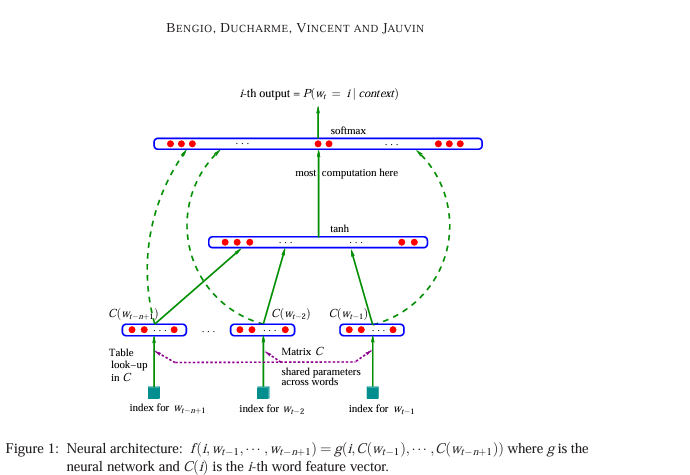

In [106]:
C = torch.randn((27, 2)) # C is a vector where each row represents each letter. the first row is '.', second row is 'a'
print(C[:2])

tensor([[1.1907, 0.1706],
        [1.1794, 0.5467]])


C is an embedding table: a matrix that maps each character index to a small vector of numbers.

In this notebook, C has shape (27, 2):

a. 27 = number of possible characters (vocabulary size, e.g. '.' plus 26 letters).

b. 2 = embedding dimension (how many features per character).

X is a tensor of indices with shape (N, block_size), e.g. (N, 3):

a. Each row is one context of block_size characters.

b. Each entry is an integer in 0..26 pointing to a row in C.

When we do emb = C[X]:

a. Each index in X is used to look up a row of C (its embedding vector).

b. This adds the embedding dimension as a new last axis.

c. If X.shape == (N, 3) and C.shape == (27, 2), then emb.shape == (N, 3, 2):

        N = number of training examples (transitions).

        3 = context length (block_size).

        2 = embedding dimension.
```        
C = torch.tensor([
    [ 1.0,  0.0],   # index 0 -> "."
    [ 0.0,  1.0],   # index 1 -> "a"
    [-1.0,  0.5],   # index 2 -> "b"
    [ 0.5, -0.5],   # index 3 -> "c"
])  # shape: (4, 2)

X = torch.tensor([
    [0, 0, 1],      # example 0: context "..a"
    [0, 1, 2],      # example 1: context ".ab"
])  # shape: (2, 3)

emb = C[X]          # shape: (2, 3, 2)
```
emb becomes:
```
tensor([
  [ [ 1.0,  0.0],   # embedding of index 0
    [ 1.0,  0.0],   # embedding of index 0
    [ 0.0,  1.0] ], # embedding of index 1

  [ [ 1.0,  0.0],   # embedding of index 0
    [ 0.0,  1.0],   # embedding of index 1
    [-1.0,  0.5] ], # embedding of index 2
])
```
So:

a. emb[0] is the 3×2 matrix for context [0, 0, 1] (i.e., "..a").

b. emb[0, 2] is the 2‑D vector for the third character in that context (index 1 → "a"), which is [0.0, 1.0].

c. emb[1, 1] is the 2‑D vector for the second character of the second example (index 1 → "a" again).
d.  emb[10, 2, 0] will give 11th matrix-> 3rd row-> first column

In [111]:
emb = C[X]
print(emb[:1])
emb.shape #(X rows, block_size, embed_dimension)



tensor([[[1.1907, 0.1706],
         [1.1907, 0.1706],
         [1.1907, 0.1706]]])


torch.Size([228146, 3, 2])


The way to read emb[i, j, k] is:

i: which example (0 to 228145).

j: which position in the context (0, 1, or 2).

k: which coordinate of the embedding vector (0 or 1).


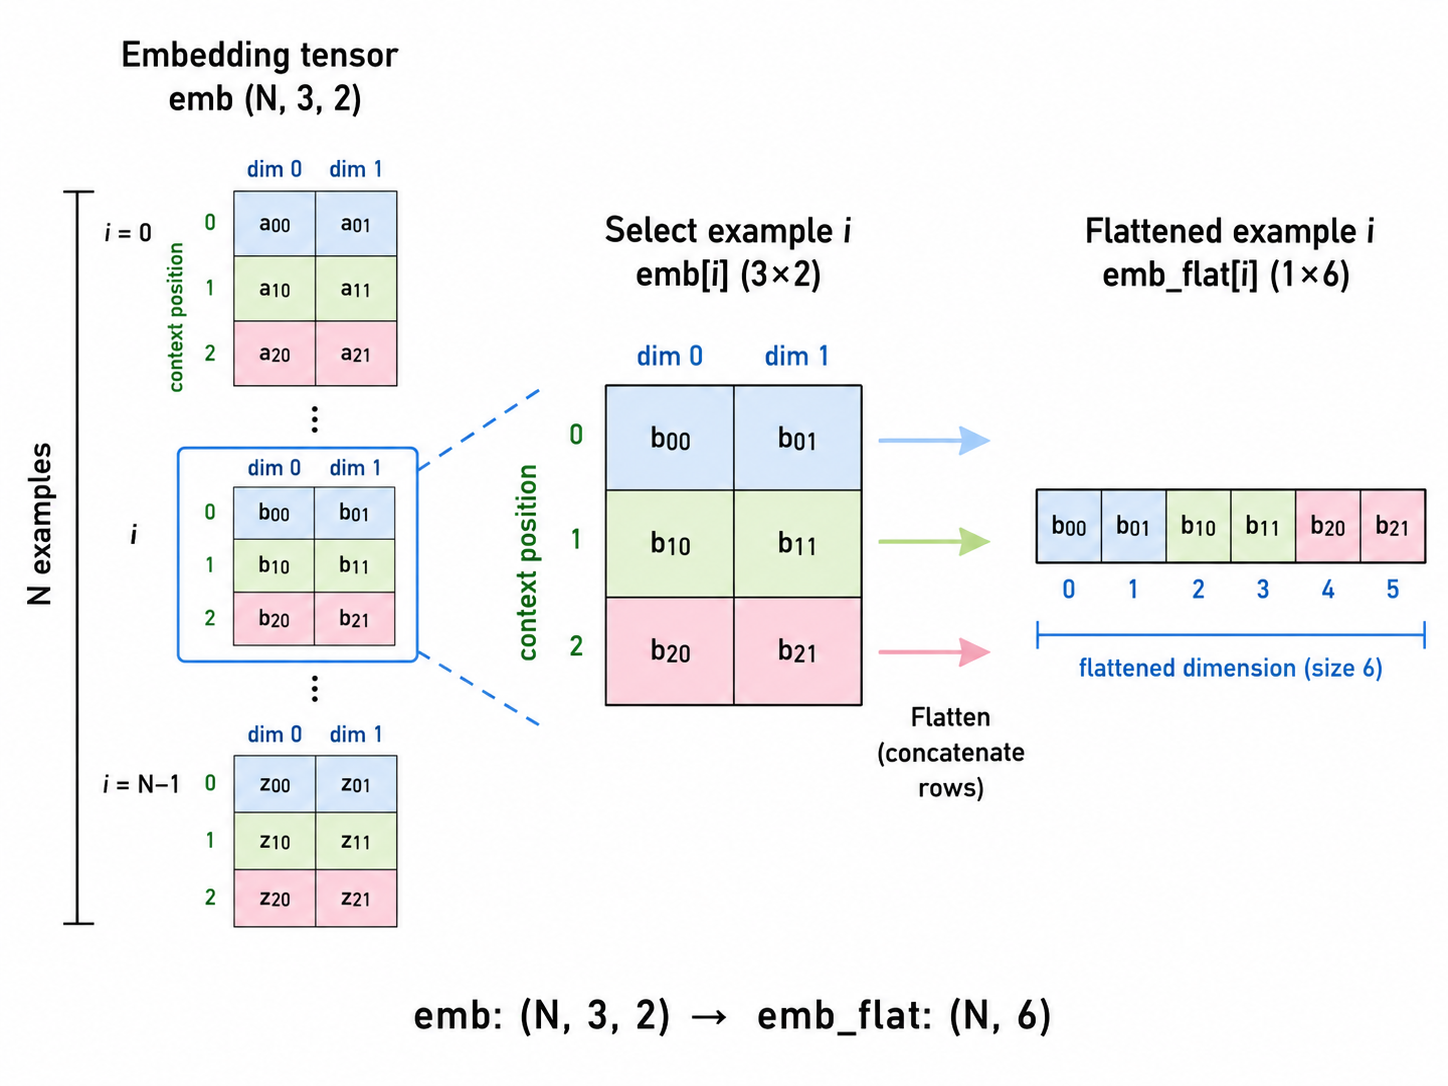

In [114]:
torch.cat((emb[:,0,:],emb[:,1,:],emb[:,2,:]),1).shape # ,1 represenets dim=1 which means stick these tensors side by side along the feature dimension, keeping the batch dimension (228146) the same.

torch.Size([228146, 6])

In [115]:
torch.cat((emb[:,0,:],emb[:,1,:],emb[:,2,:]),0).shape # ,0 represenets dim=0 which means stick these tensors one below another along the feature dimension.

torch.Size([684438, 2])

In [10]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [11]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [12]:
h

tensor([[ 0.9786, -0.3169,  0.9769,  ...,  0.7862,  0.9878,  0.0551],
        [ 0.9996,  0.1936, -0.9819,  ...,  0.9982, -0.9296, -0.9760],
        [ 0.9443, -0.1119,  0.8751,  ..., -0.2074,  0.9998, -0.2718],
        ...,
        [ 0.9545,  0.8477, -0.9118,  ..., -0.4663,  0.9758, -0.9660],
        [-0.4485,  0.9382,  0.3025,  ..., -0.9991,  0.9893,  0.9992],
        [ 0.0934, -0.9812,  0.6332,  ...,  0.9876, -0.8209, -0.9951]])

In [13]:
h.shape

torch.Size([32, 100])

In [14]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [15]:
logits = h @ W2 + b2

In [16]:
logits.shape

torch.Size([32, 27])

In [17]:
counts = logits.exp()

In [18]:
prob = counts / counts.sum(1, keepdims=True)

In [19]:
prob.shape

torch.Size([32, 27])

In [20]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(19.1027)

In [21]:
# ------------ now made respectable :) ---------------

In [22]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [23]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [24]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [25]:
for p in parameters:
  p.requires_grad = True

In [26]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [27]:
lri = []
lossi = []
stepi = []

In [28]:
for i in range(200000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

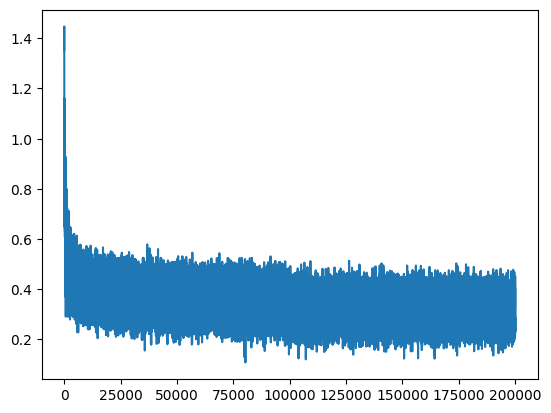

In [29]:
plt.plot(stepi, lossi)

In [30]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1312, grad_fn=<NllLossBackward0>)

In [31]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1791, grad_fn=<NllLossBackward0>)

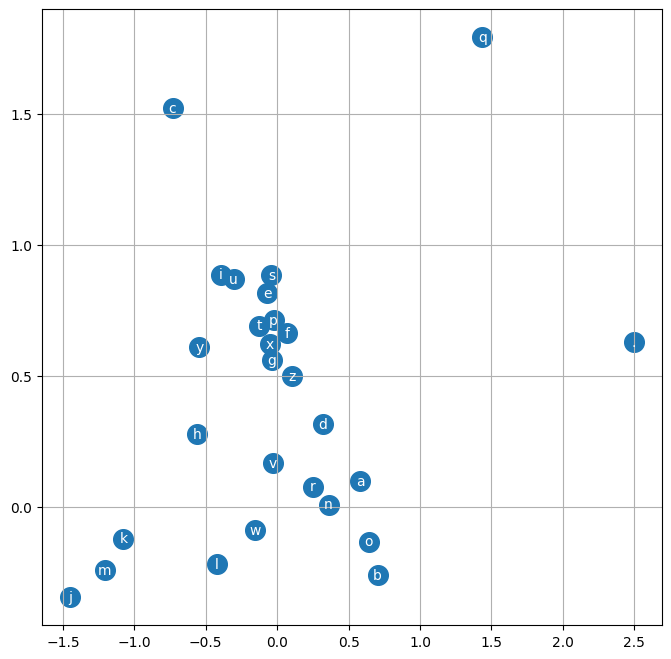

In [32]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [33]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

In [34]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [35]:


# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmahela.
jhavi.
kemlie.
taty.
salaysie.
rahnen.
delynn.
pareei.
nellara.
chaiiv.
kaleigh.
ham.
pori.
quinn.
saline.
livebi.
wavell.
dearynix.
kael.
dura.
